In [1]:
# Roboflow 및 YOLOv8 설치
!pip install roboflow ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3

In [2]:
from roboflow import Roboflow

# API 연결
rf = Roboflow(api_key="1R0h7dpWnUesIXZTWQnf")

# 정확한 workspace 및 프로젝트 ID 입력
project = rf.workspace("wiredamagedetect").project("wire_damage_byson_v3-eozdy")

# 버전 2를 YOLOv8 포맷으로 다운로드
dataset = project.version(2).download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Wire_damage_byson_v3-2 in yolov8:: 100%|██████████| 400/400 [00:00<00:00, 9333.07it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO

# 원하는 YOLOv8 모델 로딩 (yolov8n.pt, yolov8s.pt 등 선택 가능)
model = YOLO("yolov8n.pt")  # 가장 가벼운 모델

# 학습 실행
model.train(
    data=dataset.location + "/data.yaml",  # data.yaml 경로
    epochs=50,                             # 학습 횟수
    imgsz=640,                             # 이미지 크기
    batch=16,                              # 배치 사이즈 (GPU 사양 따라 조정 가능)
    name="wire_damage_byson_v3_yolov8n"    # 저장 폴더 이름
)


Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Wire_damage_byson_v3-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=wire_damage_byson_v3_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1036.7±509.4 MB/s, size: 36.0 KB)


train: Scanning /content/Wire_damage_byson_v3-2/train/labels... 168 images, 87 backgrounds, 0 corrupt: 100%|██████████| 168/168 [00:00<00:00, 1940.41it/s]

...

                   all         13          7       0.99          1      0.995      0.587



50 epochs completed in 0.018 hours.
Optimizer stripped from runs/detect/wire_damage_byson_v3_yolov8n/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/wire_damage_byson_v3_yolov8n/weights/best.pt, 6.2MB

Validating runs/detect/wire_damage_byson_v3_yolov8n/weights/best.pt...
Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 20.26it/s]


                   all         13          7       0.99          1      0.995       0.63
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/wire_damage_byson_v3_yolov8n


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a98e03cb110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [4]:
!ls runs/detect/wire_damage_byson_v3_yolov8n


args.yaml			 labels_correlogram.jpg  train_batch440.jpg
BoxF1_curve.png			 labels.jpg		 train_batch441.jpg
BoxP_curve.png			 results.csv		 train_batch442.jpg
BoxPR_curve.png			 results.png		 val_batch0_labels.jpg
BoxR_curve.png			 train_batch0.jpg	 val_batch0_pred.jpg
confusion_matrix_normalized.png  train_batch1.jpg	 weights
confusion_matrix.png		 train_batch2.jpg


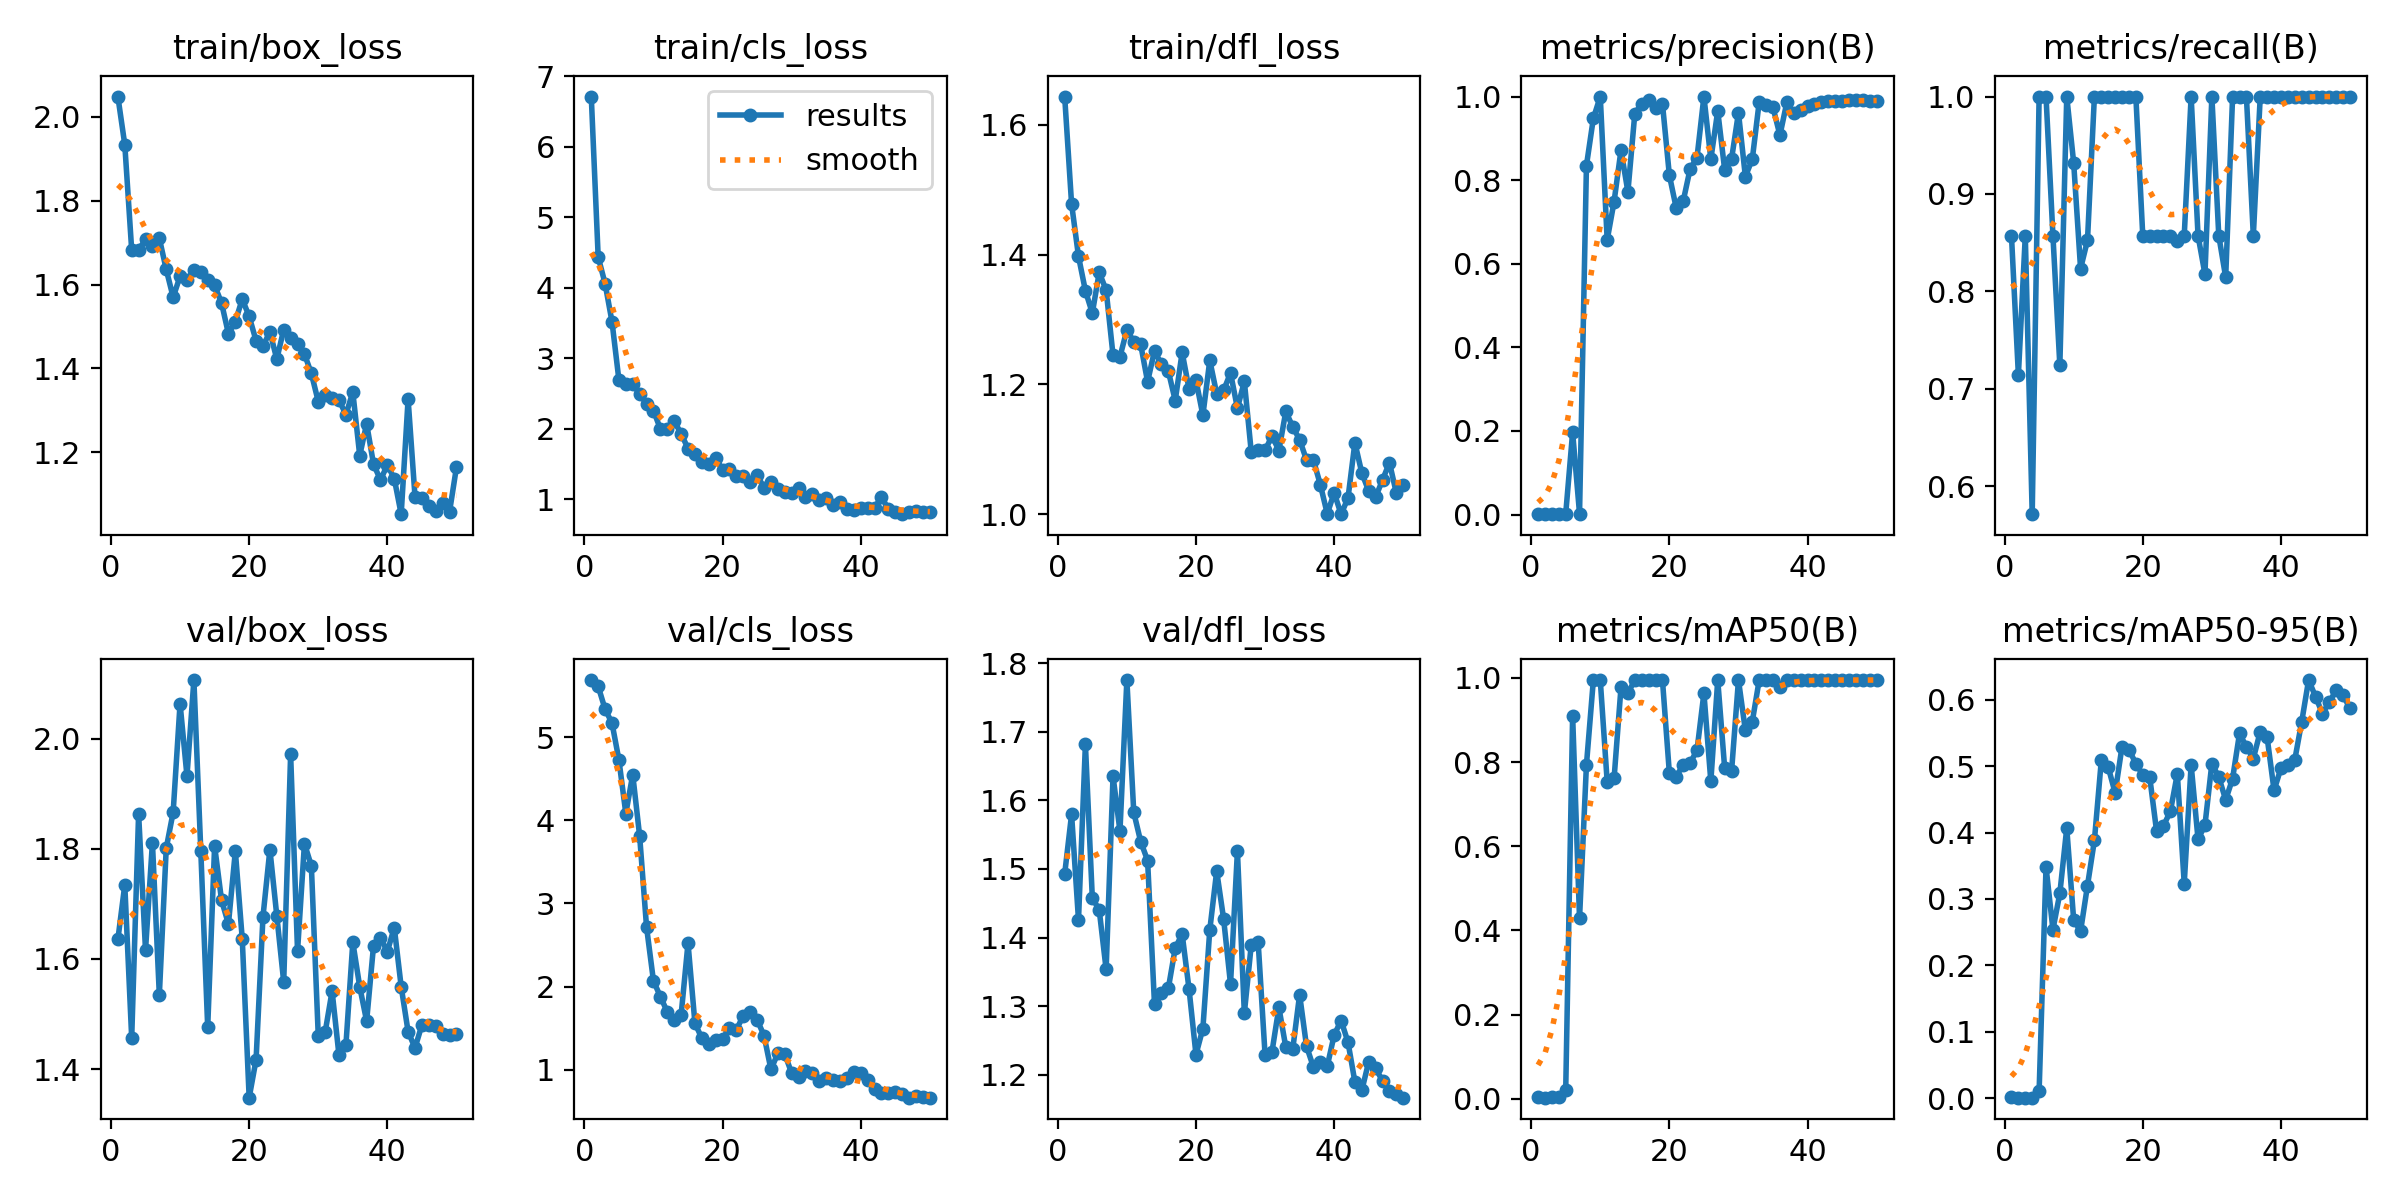

In [5]:
from IPython.display import Image

Image(filename='runs/detect/wire_damage_byson_v3_yolov8n/results.png')


In [6]:
!ls /content/runs/detect/


wire_damage_byson_v3_yolov8n


In [7]:
from ultralytics import YOLO

# 학습된 모델 로드 (v3_yolov8n)
model = YOLO("/content/runs/detect/wire_damage_byson_v3_yolov8n/weights/best.pt")


In [8]:
results = model.predict(source="/content/Wire_damage_byson_v3-2/test/images", save=True, conf=0.25)



image 1/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135401836_03_jpg.rf.e9860dbcbec03fdbe2ab52f0c58794c0.jpg: 640x640 3 damages, 8.3ms
image 2/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135430701_jpg.rf.372d968e312481997f099692ded9b352.jpg: 640x640 2 damages, 7.6ms
image 3/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135521262_02_jpg.rf.be651637d138548e1c2cc0f1766b98f6.jpg: 640x640 (no detections), 8.3ms
image 4/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135521262_jpg.rf.040732fc283331c57b395562dde80515.jpg: 640x640 (no detections), 7.3ms
image 5/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135544425_01_jpg.rf.3d7f2dc5e59926ba5cb567459235c058.jpg: 640x640 1 damage, 7.3ms
image 6/13 /content/Wire_damage_byson_v3-2/test/images/KakaoTalk_20250724_135544425_06_jpg.rf.c65c9d5d747c81b968c6dd0a7b1102da.jpg: 640x640 1 damage, 7.3ms
image 7/13 /content/Wire_damage_byson_v3-2/test/image

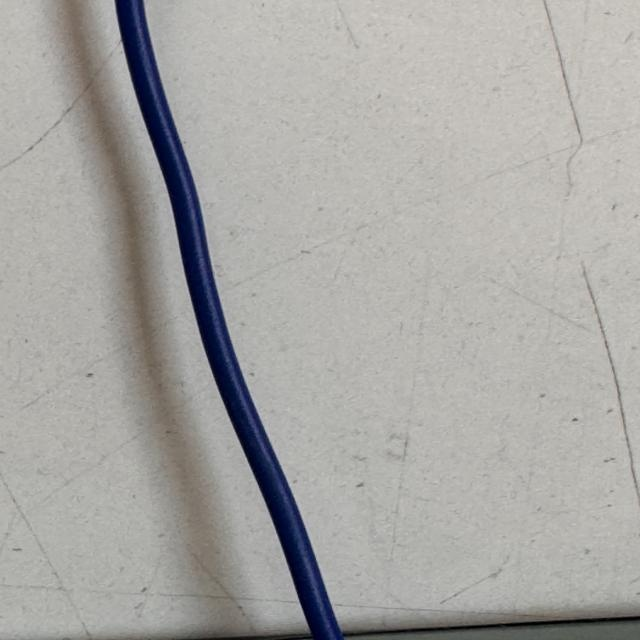

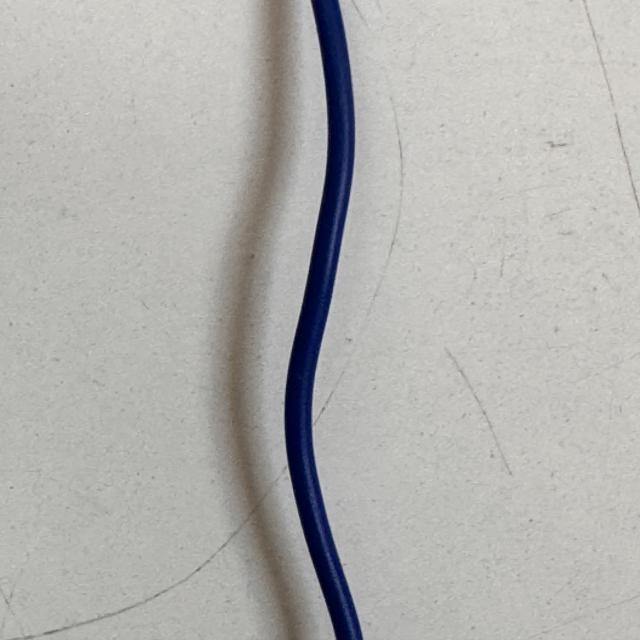

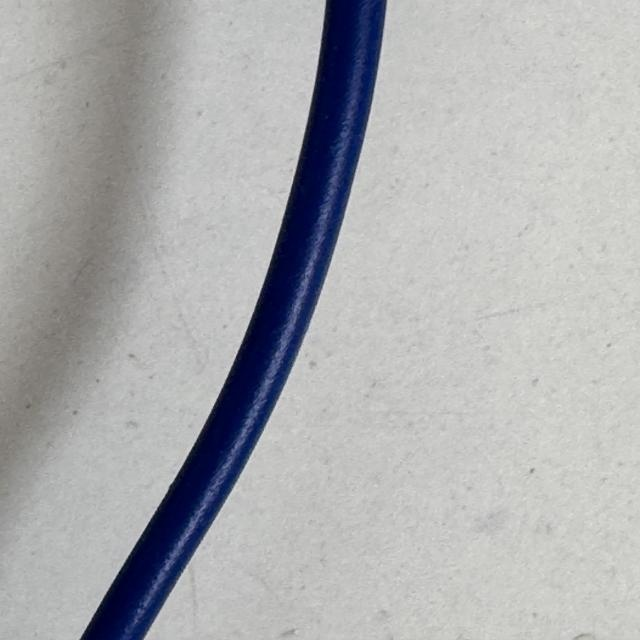

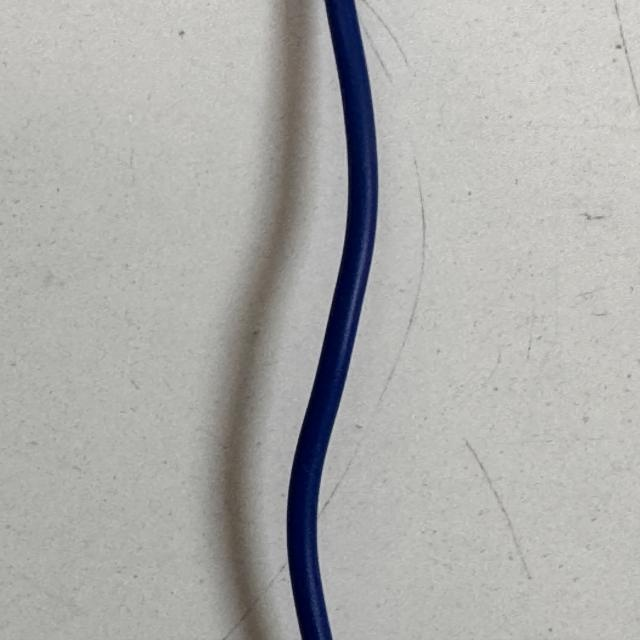

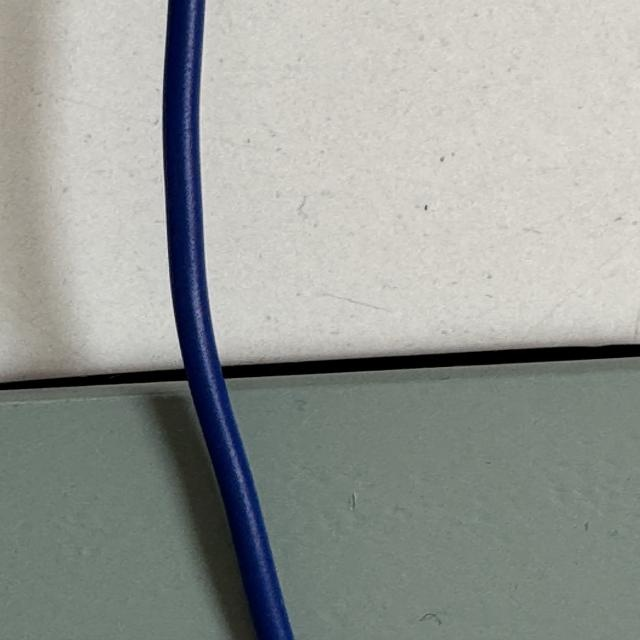

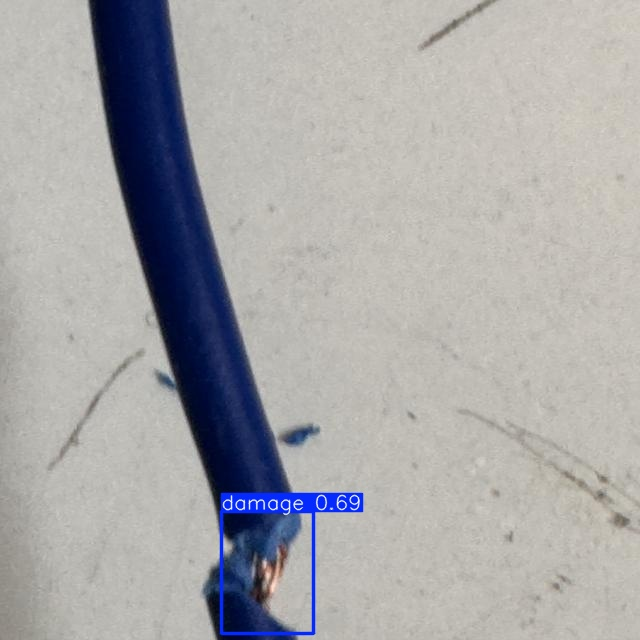

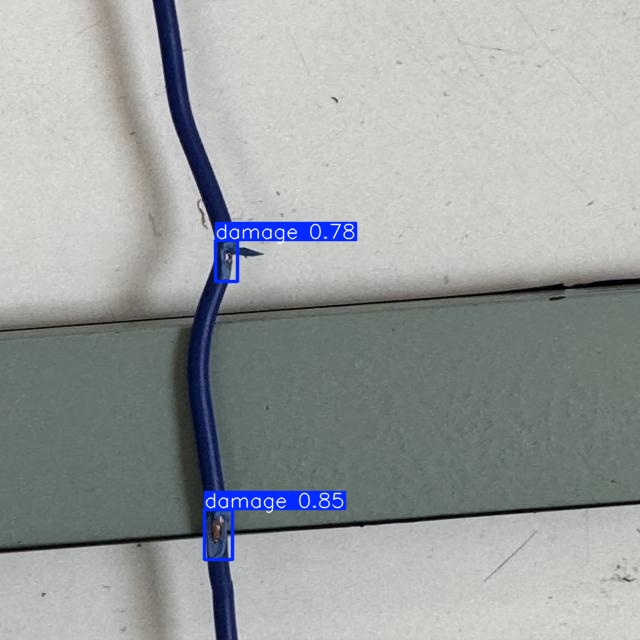

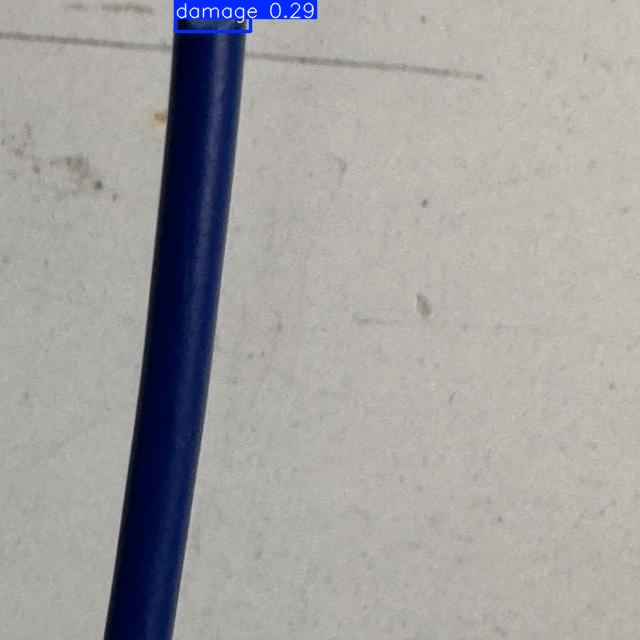

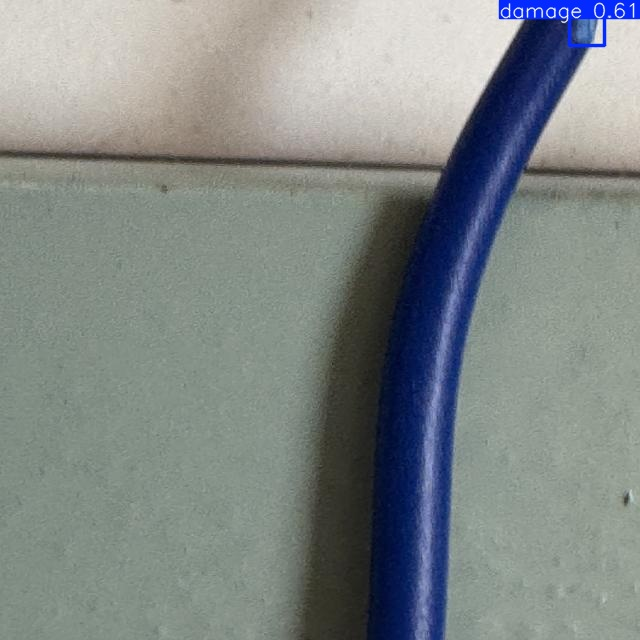

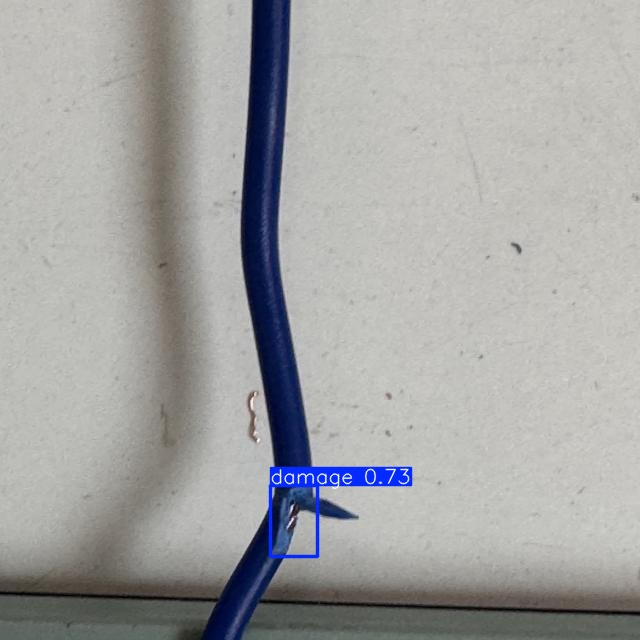

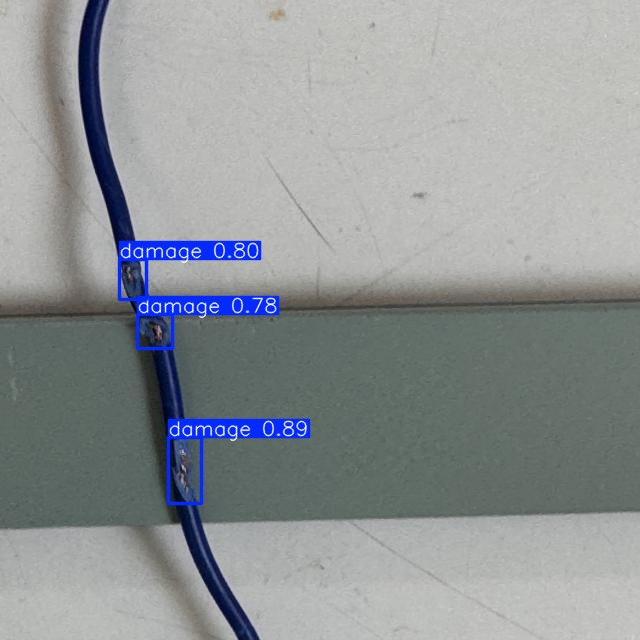

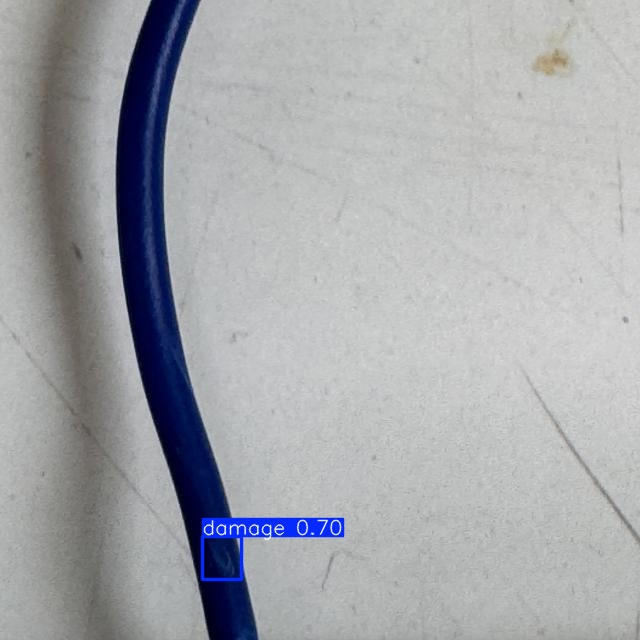

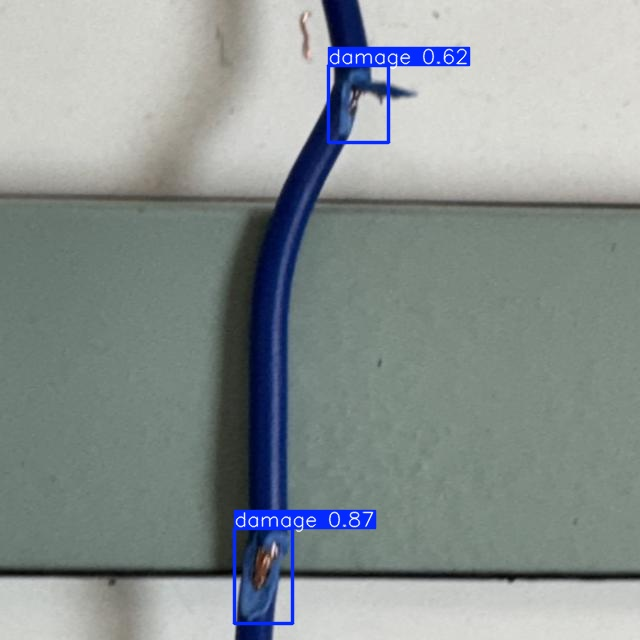

In [9]:
import glob
from IPython.display import Image, display

# 예측된 이미지 결과 중 일부 보기
result_images = glob.glob("/content/runs/detect/predict/*.jpg")

for img_path in result_images[:13]:  # 앞의 13개만 출력
    display(Image(filename=img_path))


In [11]:
from google.colab import files
files.download('/content/runs/detect/wire_damage_byson_v3_yolov8n/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
files.download(dataset.location + "/data.yaml")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>